In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model='gpt-4o')
small_llm = ChatOpenAI(model='gpt-4o-mini')

In [3]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    query: str 
    answer: str 
    context: str
graph_builder = StateGraph(AgentState)

In [4]:
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field
from typing import Literal

class Route(BaseModel):
    target: Literal['income_tax', 'llm', 'real_estate_tax'] = Field(
        description="The target for the query to answer"
    )

router_system_prompt = """
    You are an expert at routing a user's question to 'income_tax', 'llm', or 'real_estate_tax'.
    'income_tax' contains information about income tax up to january 2026.
    'real_estate_tax' contains information about real estate tax up to january 2026.
    if you think the question is not related to either 'income_tax' or 'real_estate_tax';
    you can route it to 'llm'."""


router_prompt = ChatPromptTemplate.from_messages([
    ("system", router_system_prompt),
    ("user", "{query}")
])

structured_router_llm = small_llm.with_structured_output(Route)
                                        
def router(state:AgentState) -> Literal['vector_store', 'llm', 'web_search']:
    query = state['query']
    router_chain = router_prompt | structured_router_llm
    route = router_chain.invoke({'query': query})
    return route.target

In [5]:
from langchain_core.output_parsers import StrOutputParser

def call_llm(state: AgentState) -> AgentState:
    query = state['query']
    llm_chain = small_llm | StrOutputParser()
    llm_answer = llm_chain.invoke({'query': query})
    return {'answer': llm_answer}

In [6]:
from income_tax_graph import graph as income_tax_agent
from real_estate_tax_graph import graph as real_estate_tax_agent

graph_builder.add_node('income_tax_agent', income_tax_agent)
graph_builder.add_node('real_estate_tax_agent', real_estate_tax_agent)
graph_builder.add_node('llm', call_llm)

In [8]:
from langgraph.graph import START, END

graph_builder.add_conditional_edges(
    START,
    router,
    {
        'income_tax': 'income_tax_agent',
        'real_estate_tax': 'real_estate_tax_agent',
        'llm': 'llm'
    }
)
graph_builder.add_edge('income_tax_agent', END)
graph_builder.add_edge('real_estate_tax_agent', END)
graph_builder.add_edge('llm', END)

In [9]:
graph = graph_builder.compile()

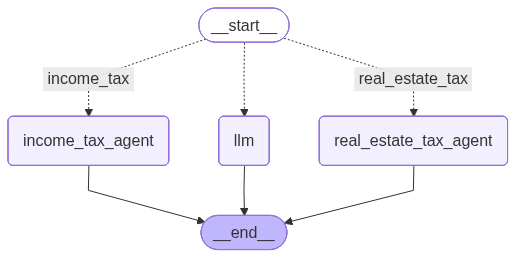

In [10]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [11]:
initial_state = {'query': '소득세란 무엇인가요?'}
graph.invoke(initial_state)

RateLimitError: Error code: 429 - {'error': {'message': 'Rate limit reached for gpt-4o in organization org-ZT7XPFYLMRYvlohwjQxLZiRN on tokens per min (TPM): Limit 30000, Used 28353, Requested 1720. Please try again in 146ms. Visit https://platform.openai.com/account/rate-limits to learn more.', 'type': 'tokens', 'param': None, 'code': 'rate_limit_exceeded'}}